This script read in numerical order, all the json files dumped from the rocket memory, and plot the data over time.

In [3]:
import json
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline

def extract_file_number(filename):
    """Extracts the integer number from the filename for correct numerical sorting."""
    match = re.search(r'flash_logs/JSON_data_(\d+)\.json', filename)
    return int(match.group(1)) if match else -1

def load_and_parse_data(folder_path="."):
    """Loads all matching JSON files and separates data by sensor type."""
    file_pattern = os.path.join(folder_path, 'flash_logs/JSON_data_*.json')
    files = glob.glob(file_pattern)
    files.sort(key=extract_file_number)
    
    if not files:
        print("No files found matching the pattern 'flash_logs/JSON_data_*.json'.")
        return pd.DataFrame(), pd.DataFrame()

    bno_data_list = []
    ms_data_list = []

    for file in files:
        with open(file, 'r') as f:
            try:
                data = json.load(f)
                for item in data:
                    if item.get('content') is not None:
                        content = item['content']
                        source = content.get('source')
                        sensor_data = content.get('sensorData')
                        
                        if source == 'BNO055':
                            bno_data_list.append(sensor_data)
                        elif source == 'MS561101BA03':
                            ms_data_list.append(sensor_data)
                            
            except json.JSONDecodeError:
                print(f"Warning: Could not decode {file}. It might be malformed.")

    df_bno = pd.DataFrame(bno_data_list)
    df_ms = pd.DataFrame(ms_data_list)

    if not df_bno.empty:
        df_bno.sort_values('timestamp', inplace=True)
    if not df_ms.empty:
        df_ms.sort_values('timestamp', inplace=True)

    return df_bno, df_ms

def visualize_data(df_bno, df_ms):
    """Plots the sensor data using matplotlib inline."""
    if df_bno.empty and df_ms.empty:
        print("No data available to plot.")
        return

    fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=False)

    # Plot Acceleration
    if not df_bno.empty and 'acceleration_x' in df_bno.columns:
        # magnitude of acceleration vector
        acceleration_mag = (df_bno['acceleration_x']**2 + df_bno['acceleration_y']**2 + df_bno['acceleration_z']**2)**0.5

        axes[0].plot(df_bno['timestamp'], df_bno['acceleration_x'], label='X', alpha=0.8)
        axes[0].plot(df_bno['timestamp'], df_bno['acceleration_y'], label='Y', alpha=0.8)
        axes[0].plot(df_bno['timestamp'], df_bno['acceleration_z'], label='Z', alpha=0.8)
        axes[0].plot(df_bno['timestamp'], acceleration_mag, label='Acceleration Magnitude', color='blue', linewidth=2)
        axes[0].set_title('BNO055: Acceleration', fontsize=14)
        axes[0].set_ylabel('m/s²')
        axes[0].legend(loc='upper right')
        axes[0].grid(True, linestyle='--', alpha=0.6)

    # Plot Angular Velocity
    if not df_bno.empty and 'angular_velocity_x' in df_bno.columns:
        axes[1].plot(df_bno['timestamp'], df_bno['angular_velocity_x'], label='X', alpha=0.8)
        axes[1].plot(df_bno['timestamp'], df_bno['angular_velocity_y'], label='Y', alpha=0.8)
        axes[1].plot(df_bno['timestamp'], df_bno['angular_velocity_z'], label='Z', alpha=0.8)
        axes[1].set_title('BNO055: Angular Velocity', fontsize=14)
        axes[1].set_ylabel('rad/s')
        axes[1].legend(loc='upper right')
        axes[1].grid(True, linestyle='--', alpha=0.6)

    # Plot Pressure
    if not df_ms.empty and 'pressure' in df_ms.columns:
        axes[2].plot(df_ms['timestamp'], df_ms['pressure'], color='purple', label='Pressure', linewidth=2)
        axes[2].set_title('MS5611: Barometric Pressure', fontsize=14)
        axes[2].set_ylabel('Pascals (Pa)')
        axes[2].legend(loc='upper right')
        axes[2].grid(True, linestyle='--', alpha=0.6)

    # Plot Temperature
    if not df_bno.empty and 'temperature' in df_bno.columns:
        axes[3].plot(df_bno['timestamp'], df_bno['temperature'], label='BNO055 Temp', alpha=0.8)
    if not df_ms.empty and 'temperature' in df_ms.columns:
        axes[3].plot(df_ms['timestamp'], df_ms['temperature'], label='MS5611 Temp', alpha=0.8, linestyle='--')
    
    axes[3].set_title('Temperature Comparison', fontsize=14)
    axes[3].set_ylabel('°C')
    axes[3].set_xlabel('Timestamp')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [4]:
print("Loading data...")
bno_dataframe, ms_dataframe = load_and_parse_data()

print(f"Loaded {len(bno_dataframe)} BNO055 records and {len(ms_dataframe)} MS5611 records.")
print("Generating plots...")
visualize_data(bno_dataframe, ms_dataframe)

Loading data...
Loaded 0 BNO055 records and 0 MS5611 records.
Generating plots...
No data available to plot.


In [2]:
df.shape

NameError: name 'df' is not defined

Loading simulated sensor data...
Loaded records: IMU (330), LIS3DH (330), MS5611_1 (330), MS5611_2 (330), GPS(330)
Generating plots...


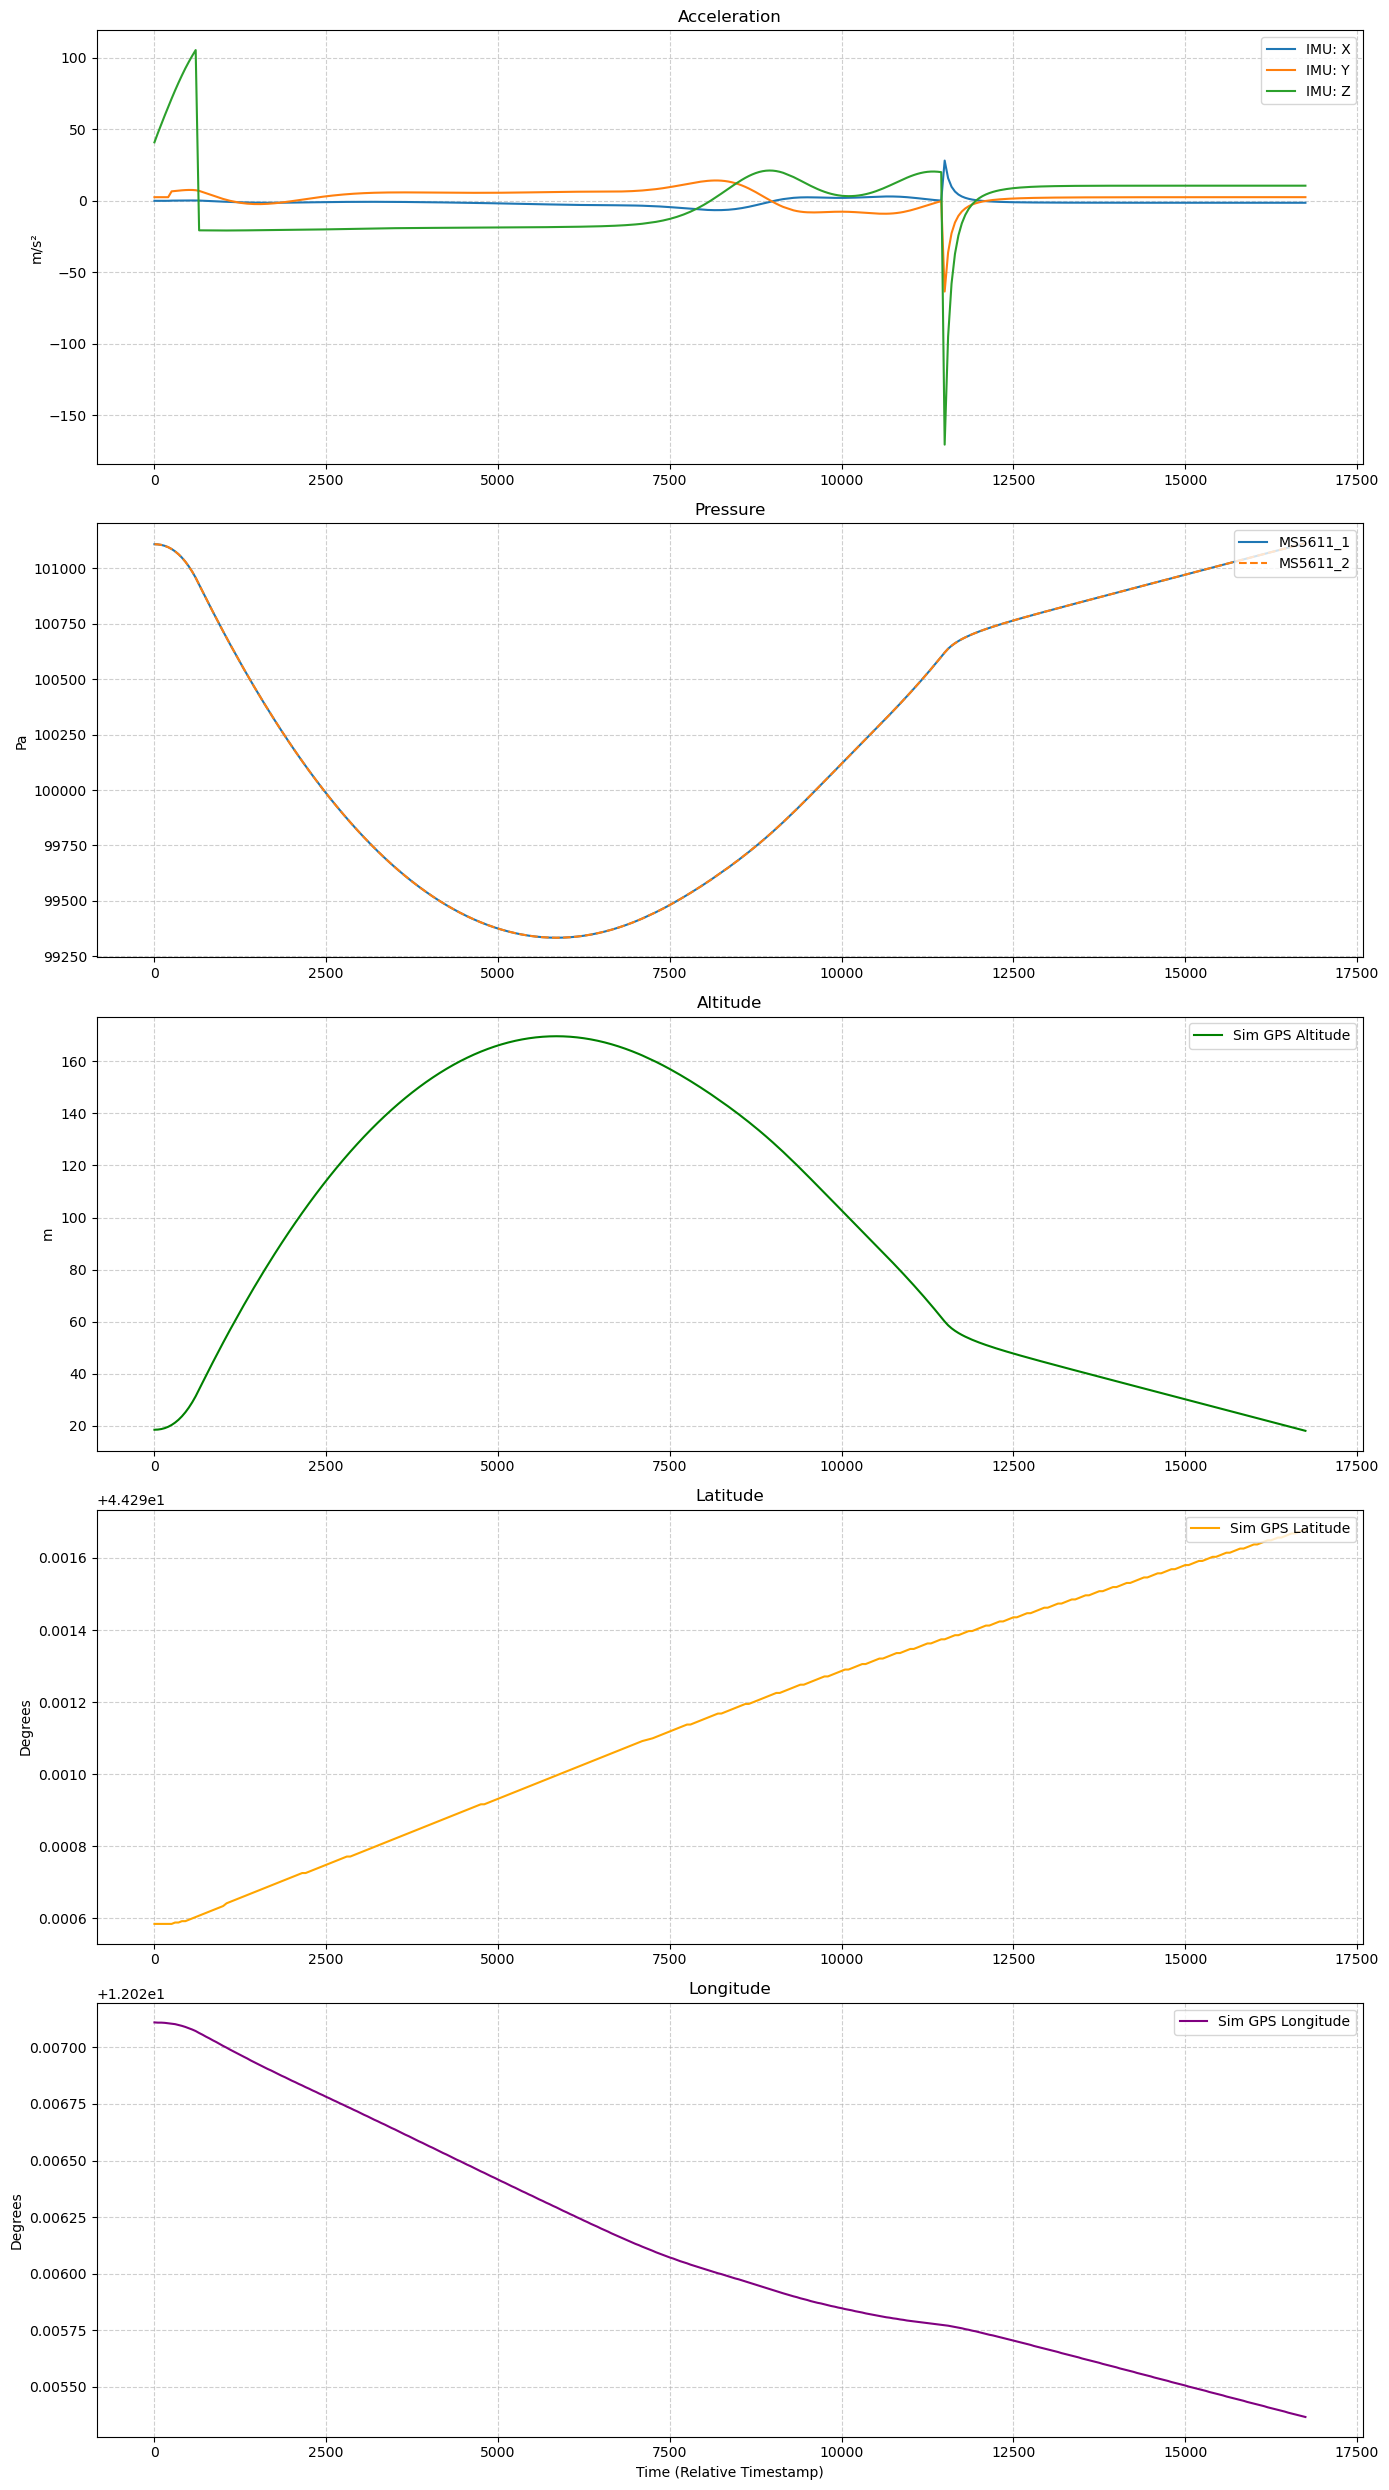

In [1]:
import json
import glob
import re
import os
import pandas as pd
import matplotlib.pyplot as plt

def extract_file_number(filename):
    """Extracts the integer number from the filename for correct numerical sorting."""
    match = re.search(r'flash_logs/JSON_data_(\d+)\.json', filename)
    return int(match.group(1)) if match else -1

def remove_extreme_outliers(df):
    """Removes physically impossible rogue spikes from sensor data."""
    if df.empty:
        return df
    
    accel_cols = [c for c in df.columns if 'acceleration' in c.lower()]
    
    for col in accel_cols:
        df = df[(df[col] >= -300) & (df[col] <= 300)]
        
    return df

def load_and_parse_sim_data(folder_path="."):
    """Loads all matching JSON files and separates data by simulated sensor type."""
    file_pattern = os.path.join(folder_path, 'flash_logs/JSON_data_*.json')
    files = glob.glob(file_pattern)
    files.sort(key=extract_file_number)
    
    if not files:
        print("No files found matching the pattern 'flash_logs/JSON_data_*.json'.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    sim_imu_data = []
    sim_lis3dh_data = []
    sim_ms5611_1_data = []
    sim_ms5611_2_data = []
    sim_gps_data = []

    for file in files:
        with open(file, 'r') as f:
            try:
                data = json.load(f)
                for item in data:
                    content = item.get('content')
                    if content is not None:
                        source = content.get('source')
                        sensor_data = content.get('sensorData')
                        
                        if source == 'Sim_IMU':
                            sim_imu_data.append(sensor_data)
                        elif source == 'Sim_LIS3DH':
                            sim_lis3dh_data.append(sensor_data)
                        elif source == 'Sim_MS5611_1':
                            sim_ms5611_1_data.append(sensor_data)
                        elif source == 'Sim_MS5611_2':
                            sim_ms5611_2_data.append(sensor_data)
                        elif source == 'Sim_GPS':
                            sim_gps_data.append(sensor_data)
                            
            except json.JSONDecodeError:
                print(f"Warning: Could not decode {file}. It might be malformed.")

    df_imu = pd.DataFrame(sim_imu_data)
    df_lis = pd.DataFrame(sim_lis3dh_data)
    df_ms1 = pd.DataFrame(sim_ms5611_1_data)
    df_ms2 = pd.DataFrame(sim_ms5611_2_data)
    df_gps = pd.DataFrame(sim_gps_data)

    # --- INLINE BULLETPROOF FILTERING ---
    
    if True:
        if not df_imu.empty: 
            df_imu.sort_values('timestamp', inplace=True)
            # Force numeric types and filter inline
            for col in ['acceleration_x', 'acceleration_y', 'acceleration_z']:
                if col in df_imu.columns:
                    df_imu[col] = pd.to_numeric(df_imu[col], errors='coerce')
                    df_imu = df_imu[(df_imu[col] >= -300) & (df_imu[col] <= 300)]
                    
        if not df_lis.empty: 
            df_lis.sort_values('timestamp', inplace=True)
            for col in ['acceleration_x', 'acceleration_y', 'acceleration_z']:
                if col in df_lis.columns:
                    df_lis[col] = pd.to_numeric(df_lis[col], errors='coerce')
                    df_lis = df_lis[(df_lis[col] >= -300) & (df_lis[col] <= 300)]

        if not df_ms1.empty: df_ms1.sort_values('timestamp', inplace=True)
        if not df_ms2.empty: df_ms2.sort_values('timestamp', inplace=True)
        if not df_gps.empty: df_gps.sort_values('timestamp', inplace=True)
    else:
        if not df_imu.empty: 
            df_imu.sort_values('timestamp', inplace=True)
        if not df_lis.empty: 
            df_lis.sort_values('timestamp', inplace=True)
        if not df_ms1.empty: 
            df_ms1.sort_values('timestamp', inplace=True)
        if not df_ms2.empty: 
            df_ms2.sort_values('timestamp', inplace=True)
        if not df_gps.empty: 
            df_gps.sort_values('timestamp', inplace=True)
    return df_imu, df_lis, df_ms1, df_ms2, df_gps

def visualize_sim_data(df_imu, df_lis, df_ms1, df_ms2, df_gps):
    """Plots the simulated sensor data."""
    if df_imu.empty and df_lis.empty and df_ms1.empty and df_ms2.empty and df_gps.empty:
        print("No simulated data available to plot.")
        return

    # Find the global minimum timestamp to normalize all times to start at 0
    t0_candidates = []
    if not df_imu.empty: t0_candidates.append(df_imu['timestamp'].min())
    if not df_lis.empty: t0_candidates.append(df_lis['timestamp'].min())
    if not df_ms1.empty: t0_candidates.append(df_ms1['timestamp'].min())
    if not df_ms2.empty: t0_candidates.append(df_ms2['timestamp'].min())
    if not df_gps.empty: t0_candidates.append(df_gps['timestamp'].min())
    
    t0 = min(t0_candidates) if t0_candidates else 0

    fig, axes = plt.subplots(5, 1, figsize=(14, 25), sharex=False)

    # Plot Acceleration
    if not df_imu.empty:
        axes[0].plot(df_imu['timestamp'] - t0, df_imu['acceleration_x'], label='IMU: X')
        axes[0].plot(df_imu['timestamp'] - t0, df_imu['acceleration_y'], label='IMU: Y')
        axes[0].plot(df_imu['timestamp'] - t0, df_imu['acceleration_z'], label='IMU: Z')

    axes[0].set_title('Acceleration')
    axes[0].set_ylabel('m/s²')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(loc='upper right')

    # Plot Pressure
    if not df_ms1.empty:
        axes[1].plot(df_ms1['timestamp'] - t0, df_ms1['pressure'], label='MS5611_1')
    if not df_ms2.empty:
        axes[1].plot(df_ms2['timestamp'] - t0, df_ms2['pressure'], label='MS5611_2', linestyle='--')
    axes[1].set_title('Pressure')
    axes[1].set_ylabel('Pa')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(loc='upper right')

    # Plot Altitude
    if not df_gps.empty and 'altitude' in df_gps.columns:
        axes[2].plot(df_gps['timestamp'] - t0, df_gps['altitude'], label='Sim GPS Altitude', color='green')
    axes[2].set_title('Altitude')
    axes[2].set_ylabel('m')
    axes[2].grid(True, linestyle='--', alpha=0.6)
    axes[2].legend(loc='upper right')

    # Plot Latitude
    if not df_gps.empty and 'latitude' in df_gps.columns:
        axes[3].plot(df_gps['timestamp'] - t0, df_gps['latitude'], label='Sim GPS Latitude', color='orange')
    axes[3].set_title('Latitude')
    axes[3].set_ylabel('Degrees')
    axes[3].grid(True, linestyle='--', alpha=0.6)
    axes[3].legend(loc='upper right')

    # Plot Longitude
    if not df_gps.empty and 'longitude' in df_gps.columns:
        axes[4].plot(df_gps['timestamp'] - t0, df_gps['longitude'], label='Sim GPS Longitude', color='purple')
    axes[4].set_title('Longitude')
    axes[4].set_ylabel('Degrees')
    axes[4].set_xlabel('Time (Relative Timestamp)')
    axes[4].grid(True, linestyle='--', alpha=0.6)
    axes[4].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

print("Loading simulated sensor data...")
df_imu, df_lis, df_ms1, df_ms2, df_gps = load_and_parse_sim_data()


print(f"Loaded records: IMU ({len(df_imu)}), LIS3DH ({len(df_lis)}), MS5611_1 ({len(df_ms1)}), MS5611_2 ({len(df_ms2)}), GPS({len(df_gps)})")
print("Generating plots...")
visualize_sim_data(df_imu, df_lis, df_ms1, df_ms2, df_gps)

In [2]:
(df_imu['timestamp'] - df_imu['timestamp'][1])

0       0
1       0
2       0
3       0
4       0
       ..
325    16
326    16
327    16
328    16
329    16
Name: timestamp, Length: 330, dtype: int64